# No Flux in 2D Domain (disk)

## Setup

### Liberaries

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


import os


In [30]:
import sys
sys.path.append("..")

### Import custom functions 

In [31]:
from sources.simulation import *
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Initialization

In [36]:

#defind variables

n_parts = 100000
# n_parts = 10000000

T = 4
dt = 0.001

n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

center = np.array([0.0, 0.0])
radius = 1

boundary = lambda theta: disk_boundary(radius=radius, theta=theta)

b = np.array([0.0, 0.0])
# sigma = np.eye(2)
sigma = np.array([[1.0, 0.5],[0.0, 1.0]])

## experiments

### Inital distribution

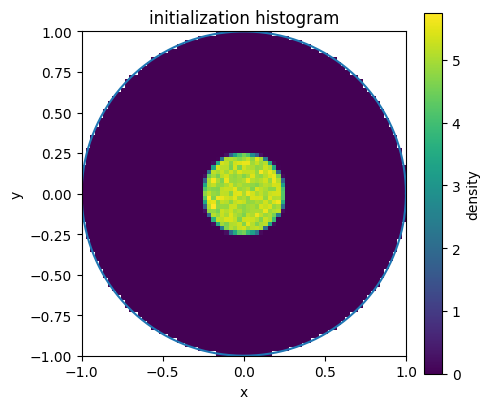

In [37]:
bins = 75

cmap = plt.get_cmap()

X_0 = initialize_disk(n_parts)

p_scale, _, _ = histogram_density_disk(X_0, radius=radius, bins=bins)
colorbar_values = get_colorbar_values_2d([p_scale])

fig, ax = plt.subplots(figsize=(5, 5))
plot_histogram_disk(X_0, radius=radius, bins=bins, ax=ax, title="initialization histogram"
                    , colorbar_values=colorbar_values, cmap=cmap)

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax, label="density", fraction=0.05, pad=0.05)

plt.tight_layout()
plt.show()

### Simulate Eular-Maruyama steps in disk domain

In [38]:


X_ref = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=("disk", radius))

X_ref_n = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps, b=b
                                                    , sigma=sigma, boundary_type="reflection_normal"
                                                    , boundaries=("disk", radius))

X_rej  = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps, b=b
                                                    , sigma=sigma, boundary_type="rejection"
                                                    , boundaries=("disk", radius))



### Plot numerical solutions

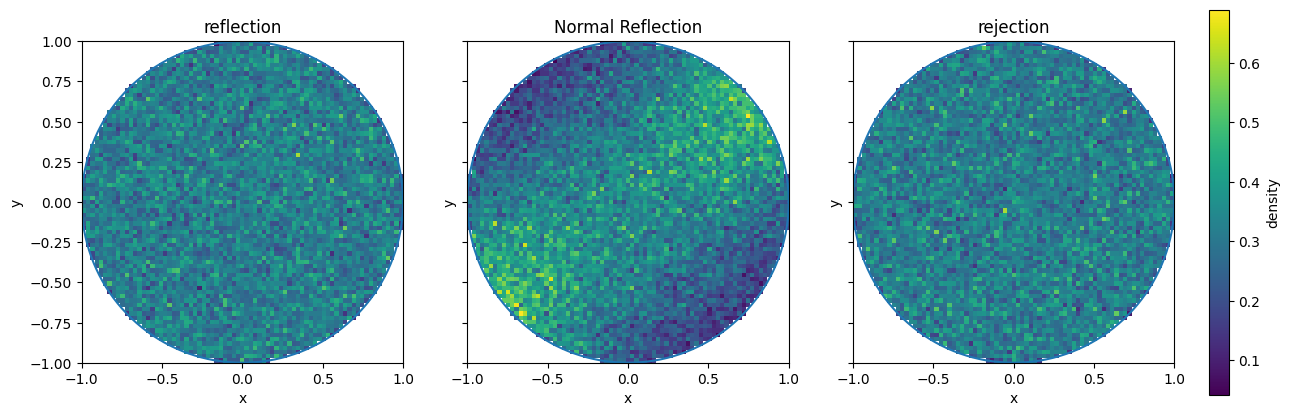

In [39]:
p_ref_scale, _, _ = histogram_density_disk(X_ref, radius=radius, bins=bins)
p_ref_n_scale, _, _ = histogram_density_disk(X_ref_n, radius=radius, bins=bins)
p_rej_scale, _, _ = histogram_density_disk(X_rej, radius=radius, bins=bins)
colorbar_values = get_colorbar_values_2d([p_ref_scale, p_ref_n_scale, p_rej_scale])

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

plot_histogram_disk(X_ref, radius=radius, bins=bins, ax=ax[0], title="reflection", colorbar_values=colorbar_values, cmap=cmap)
plot_histogram_disk(X_ref_n, radius=radius, bins=bins, ax=ax[1], title="Normal Reflection", colorbar_values=colorbar_values, cmap=cmap)
plot_histogram_disk(X_rej, radius=radius, bins=bins, ax=ax[2], title="rejection", colorbar_values=colorbar_values, cmap=cmap)


vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax.ravel().tolist(), label="density", fraction=0.03, pad=0.03)

plt.show()

## plot the density close to the boundary

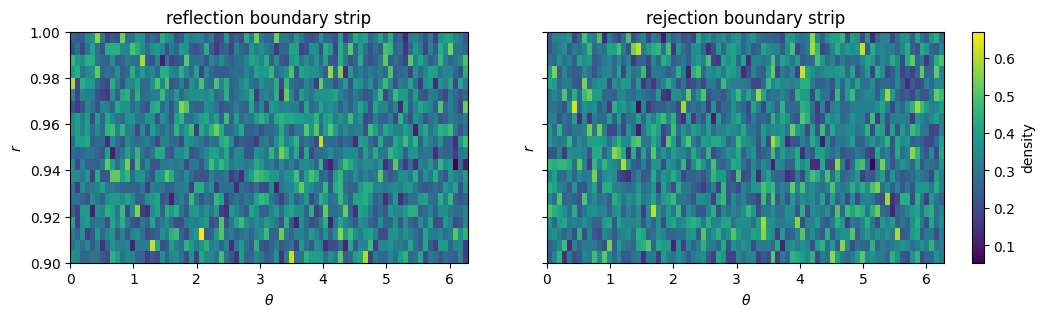

In [24]:
r_range = (radius - epsilon, radius)
theta_bins = 80
r_bins = 20

p_ref_scale, _, _, _ = density_disk_range(X_ref, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)
p_rej_scale, _, _, _ = density_disk_range(X_rej, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)
colorbar_values = get_colorbar_values_2d([p_ref_scale, p_rej_scale])

fig, ax = plt.subplots(1, 2, figsize=(12, 3), sharex=True, sharey=True)

plot_density_disk_range(X_ref, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins, ax=ax[0], title="reflection boundary strip", colorbar_values=colorbar_values, cmap=cmap)
plot_density_disk_range(X_rej, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins, ax=ax[1], title="rejection boundary strip", colorbar_values=colorbar_values, cmap=cmap)

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax.ravel().tolist(), label="density", fraction=0.03, pad=0.03)

plt.show()

## error analysis

In [9]:
r_range = (radius - epsilon, radius)
theta_bins = 80
r_bins = 20

#assume reflection is true solution for now only
p_ref, theta_edges, r_edges, _ = density_disk_range(X_ref, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)
p_rej, _, _, _ = density_disk_range(X_rej, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)

local_error_delta = local_error_density(p_rej, p_ref)


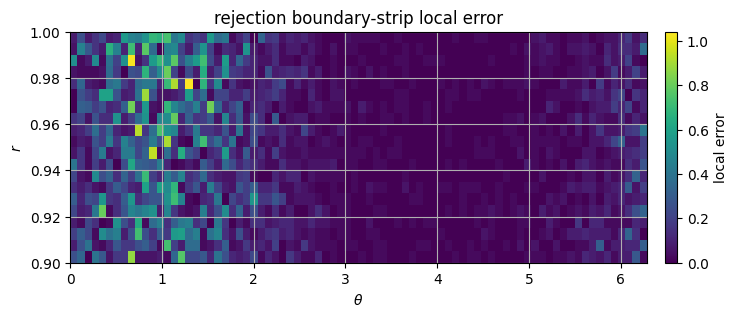

In [10]:
colorbar_values = (np.nanmin(np.abs(local_error_delta)), np.nanmax(np.abs(local_error_delta)))

fig, ax = plt.subplots(figsize=(8, 3))

plot_density_mesh(local_error_delta, theta_edges, r_edges, ax=ax, title="rejection boundary-strip local error", colorbar_values=colorbar_values, cmap=cmap, x_label=r"$\theta$", y_label=r"$r$", equal_aspect=False)

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax, label="local error", fraction=0.04, pad=0.03)

plt.show()

In [11]:
L1_error, L2_error = density_error_norms(local_error_delta, theta_edges, r_edges)

print("L1 boundary error:", L1_error)
print("L2 boundary error:", L2_error)

L1 boundary error: 0.06518
L2 boundary error: 0.15320401676610507


### stretched boundary

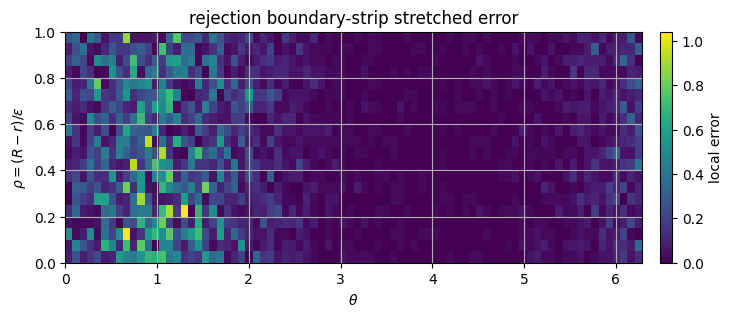

In [12]:
rho_edges = (radius - r_edges)/epsilon

colorbar_values = (np.nanmin(np.abs(local_error_delta)), np.nanmax(np.abs(local_error_delta)))

fig, ax = plt.subplots(figsize=(8, 3))

plot_density_mesh(local_error_delta, theta_edges, rho_edges, ax=ax, title="rejection boundary-strip stretched error", colorbar_values=colorbar_values, cmap=cmap, x_label=r"$\theta$", y_label=r"$\rho=(R-r)/\epsilon$", equal_aspect=False)

ax.set_ylim(rho_edges[-1], rho_edges[0])

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax, label="local error", fraction=0.04, pad=0.03)

plt.show()

### error in full domain

In [13]:
def density_error_norms_cartesian(p_error, x_edges, y_edges):
    dx = np.diff(x_edges)
    dy = np.diff(y_edges)
    bin_area = dx[:, None]*dy[None, :]

    L1_error = np.nansum(np.abs(p_error)*bin_area)
    L2_error = np.sqrt(np.nansum(p_error**2*bin_area))

    return L1_error, L2_error

L1 full-domain error: 0.18481
L2 full-domain error: 0.1823252159603822


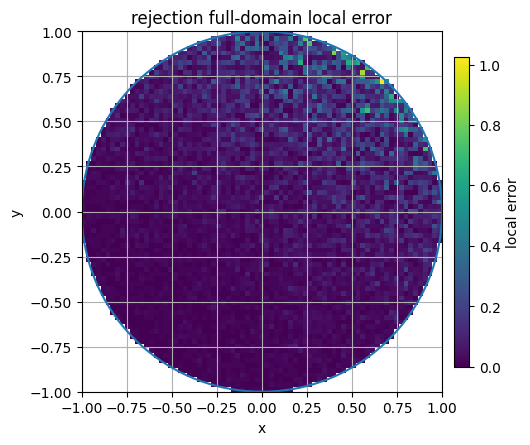

In [14]:
p_ref_full, x_edges, y_edges = histogram_density_disk(X_ref, radius=radius, bins=bins)
p_rej_full, _, _ = histogram_density_disk(X_rej, radius=radius, bins=bins)

local_error_full = local_error_density(p_rej_full, p_ref_full)

L1_full, L2_full = density_error_norms_cartesian(local_error_full, x_edges, y_edges)

print("L1 full-domain error:", L1_full)
print("L2 full-domain error:", L2_full)

colorbar_values = (np.nanmin(np.abs(local_error_full)), np.nanmax(np.abs(local_error_full)))

fig, ax = plt.subplots(figsize=(5, 5))

plot_density_mesh(local_error_full, x_edges, y_edges, ax=ax, title="rejection full-domain local error", colorbar_values=colorbar_values, cmap=cmap, x_label="x", y_label="y", equal_aspect=True)

theta = np.linspace(0, 2*np.pi, 300)
x_boundary, y_boundary = disk_boundary(radius=radius, theta=theta)
ax.plot(x_boundary, y_boundary)
ax.set_xlim(-radius, radius)
ax.set_ylim(-radius, radius)

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax, label="local error", fraction=0.04, pad=0.03)

plt.show()

In [15]:
# full-domain error
p_ref_full, x_edges, y_edges = histogram_density_disk(X_ref, radius=radius, bins=bins)
p_rej_full, _, _ = histogram_density_disk(X_rej, radius=radius, bins=bins)

error_full = p_rej_full - p_ref_full
abs_error_full = np.abs(error_full)

L1_full, L2_full = density_error_norms_cartesian(error_full, x_edges, y_edges)

# boundary-strip error
r_range = (radius - epsilon, radius)
theta_bins = 80
r_bins = 20

p_ref_boundary, theta_edges, r_edges, _ = density_disk_range(X_ref, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)
p_rej_boundary, _, _, _ = density_disk_range(X_rej, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)

error_boundary = p_rej_boundary - p_ref_boundary
abs_error_boundary = np.abs(error_boundary)

L1_boundary, L2_boundary = density_error_norms(error_boundary, theta_edges, r_edges)

# print summary
print("Full domain")
print("L1:", L1_full)
print("L2:", L2_full)

print("\nBoundary strip")
print("L1:", L1_boundary)
print("L2:", L2_boundary)

Full domain
L1: 0.18481
L2: 0.1823252159603822

Boundary strip
L1: 0.06518
L2: 0.15320401676610507


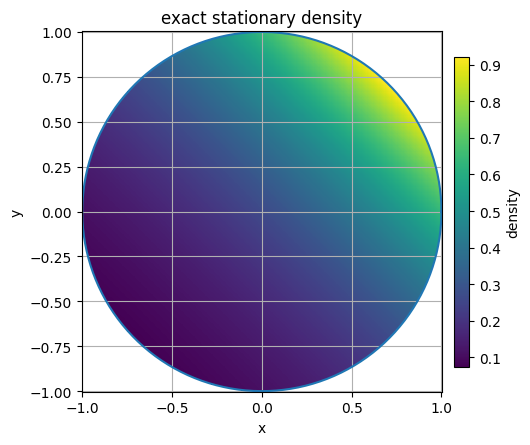

In [17]:
b = np.array([1, 1])

sigma = np.array([[1.0, 0.5],
                  [0.5, 1.0]])

x_plot = np.linspace(-radius, radius, 300)
y_plot = np.linspace(-radius, radius, 300)
x_mesh, y_mesh = np.meshgrid(x_plot, y_plot, indexing="ij")

p_exact = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

fig, ax = plt.subplots(figsize=(5, 5))

plot_density_mesh(p_exact, x_plot, y_plot, ax=ax, title="exact stationary density", cmap=cmap, equal_aspect=True)

theta = np.linspace(0, 2*np.pi, 300)
x_boundary, y_boundary = disk_boundary(radius=radius, theta=theta)
ax.plot(x_boundary, y_boundary)

fig.colorbar(ax.collections[0], ax=ax, label="density", fraction=0.04, pad=0.03)

plt.show()